## A/B-тест: оценка эффективности новой landing page

### Цель эксперимента

Цель анализа — определить, приводит ли новая версия landing page (new_page) к увеличению конверсии пользователей по сравнению со старой версией (old_page).

Пользователи были разделены на две экспериментальные группы:

- control — пользователи, которым показывалась старая версия страницы;
- treatment — пользователи, которым показывалась новая версия страницы.

### Основная метрика

В качестве основной метрики эксперимента используется **Conversion Rate (CR)** — доля пользователей, совершивших целевое действие.

### Бизнес-вопрос

Стоит ли внедрять новую версию landing page для всех пользователей?

Для ответа на этот вопрос сравнивается конверсия в контрольной и тестовой группах и проводится статистическая проверка полученной разницы.

> Проверка качества данных, SRM и баланс групп выполнены в ноутбуке `01_ab_test_analysis` (EDA). Здесь — статистический анализ результатов эксперимента.

In [11]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Загрузка данных эксперимента (одна строка — один пользователь)
df = pd.read_csv('AB Testing Data.csv')


### Conversion Rate по экспериментальным группам

Сначала рассчитываются основные показатели отдельно для контрольной и тестовой групп.

Для каждой группы определяются:

- количество пользователей;
- количество конверсий;
- Conversion Rate.

In [12]:
# Основные показатели по экспериментальным группам
group_stats = (
    df.groupby('group')['converted']
      .agg(['count', 'sum', 'mean'])      
      .rename(columns={
          'count': 'users',
          'sum': 'conversions',
          'mean': 'conversion_rate'
      })
)

# Перевод CR из доли в проценты
group_stats['conversion_rate'] *= 100

group_stats.round(2)

,users,conversions,conversion_rate
group,,,
control,146926,17444,11.87
treatment,147552,26484,17.95


### Формулировка статистических гипотез

На основании описательной статистики Conversion Rate в тестовой группе выше, чем в контрольной:

- Control — 11.87%;
- Treatment — 17.95%.

Однако наблюдаемая разница сама по себе ещё не доказывает эффективность новой версии страницы. Необходимо определить, является ли различие статистически значимым.

Для этого формулируются статистические гипотезы.

**Нулевая гипотеза H₀**

Конверсия пользователей в контрольной и тестовой группах не различается статистически значимо.

**Альтернативная гипотеза H₁**

Конверсия пользователей в контрольной и тестовой группах статистически значимо различается.

Используется двусторонний тест, уровень статистической значимости: alpha = 0.05.

Если p-value < 0.05, нулевая гипотеза отвергается, а различие считается статистически значимым.

**Conversion Rate** является долей пользователей, совершивших целевое действие.

Поскольку сравниваются две независимые группы пользователей — Control и Treatment — применяется z-тест для сравнения двух пропорций.

Уровень значимости: α = 0.05.

In [14]:
# z-тест для сравнения двух пропорций (Conversion Rate в двух независимых группах)
from statsmodels.stats.proportion import proportions_ztest

conversions = group_stats['conversions'].values
users = group_stats['users'].values

z_stat, p_value = proportions_ztest(
    count=conversions,
    nobs=users,
    alternative='two-sided'
)

print(f'Z-statistic: {z_stat:.4f}')
print(f'p-value: {p_value:.10f}')

Z-statistic: -46.2773
p-value: 0.0000000000


Результаты теста:

- Z-statistic = -46.2773;
- p-value < 0.0000000001;
- уровень значимости α = 0.05.

Так как p-value значительно меньше выбранного уровня значимости, нулевая гипотеза отвергается.

Следовательно, между конверсиями Control и Treatment существует статистически значимое различие.

При этом тест показывает только наличие статистически значимого различия. Для оценки практической значимости результата дополнительно нужно рассчитать абсолютный и относительный эффект изменения Conversion Rate, а также доверительный интервал.

> Знак статистики отрицательный только потому, что в `group_stats` группы отсортированы по алфавиту (первая — `control`). Направление эффекта — в пользу `treatment`.

### Оценка практического размера эффекта

Необходимо рассчитать:

- Absolute Uplift — абсолютное изменение Conversion Rate в процентных пунктах;
- Relative Uplift — относительное изменение Conversion Rate по сравнению с контрольной группой.

In [15]:
# Размер эффекта
# Конверсия каждой группы в долях (ранее в таблице была в процентах)
control_cr = group_stats.loc['control', 'conversion_rate'] / 100
treatment_cr = group_stats.loc['treatment', 'conversion_rate'] / 100

# Абсолютный uplift — разница CR в процентных пунктах
absolute_uplift = treatment_cr - control_cr
# Относительный uplift — прирост в процентах от CR контрольной группы
relative_uplift = absolute_uplift / control_cr

print(f'Control CR: {control_cr:.2%}')
print(f'Treatment CR: {treatment_cr:.2%}')
print(f'Absolute Uplift: {absolute_uplift:.2%}')
print(f'Relative Uplift: {relative_uplift:.2%}')

Control CR: 11.87%
Treatment CR: 17.95%
Absolute Uplift: 6.08%
Relative Uplift: 51.18%


Conversion Rate в тестовой группе составила 17.95% против 11.87% в контрольной группе.

Абсолютное изменение конверсии составляет **+6.08 процентного пункта**.

Относительно контрольной группы конверсия увеличилась примерно на **51.2%**.

Таким образом, новая версия landing page показала не только статистически значимое, но и достаточно большое с точки зрения практического эффекта увеличение Conversion Rate.

### Расчёт доверительного интервала

Для оценки неопределённости этой оценки нужно рассчитать 95% доверительный интервал для разницы между конверсиями.

Доверительный интервал позволяет определить диапазон значений, в котором находится истинная разница между конверсиями с учётом статистической неопределённости.

In [16]:
# 95% доверительный интервал для разницы конверсий (treatment − control)
from statsmodels.stats.proportion import confint_proportions_2indep

# Первая группа — treatment (индекс 1), вторая — control (индекс 0)
ci_low, ci_high = confint_proportions_2indep(
    count1=conversions[1],
    nobs1=users[1],
    count2=conversions[0],
    nobs2=users[0],
    method='wald'
)

# Если интервал целиком выше 0, эффект положительный
print(f'Absolute Uplift: {absolute_uplift:.4%}')
print(f'95% CI: [{ci_low:.4%}; {ci_high:.4%}]')

Absolute Uplift: 6.0763%
95% CI: [5.8200%; 6.3326%]


**Абсолютный прирост конверсии (Absolute Uplift)** составил 6.08 п.п. в пользу тестовой группы.

95% доверительный интервал для эффекта находится в диапазоне от 5.82 до 6.33 п.п. Это означает, что с 95% уровнем доверия истинный прирост конверсии находится в данном диапазоне.

Поскольку весь доверительный интервал находится выше 0, результаты эксперимента свидетельствуют о положительном влиянии изменения на конверсию. Эффект не только статистически значим, но и достаточно велик по абсолютной величине.

Таким образом, тестируемое изменение увеличило конверсию примерно на 6 п.п. по сравнению с контрольной группой.

Относительный прирост (+51.18% от baseline контроля) рассчитан выше вместе с абсолютным.

### Визуализация результата

Наглядное сравнение Conversion Rate в контрольной и тестовой группах.

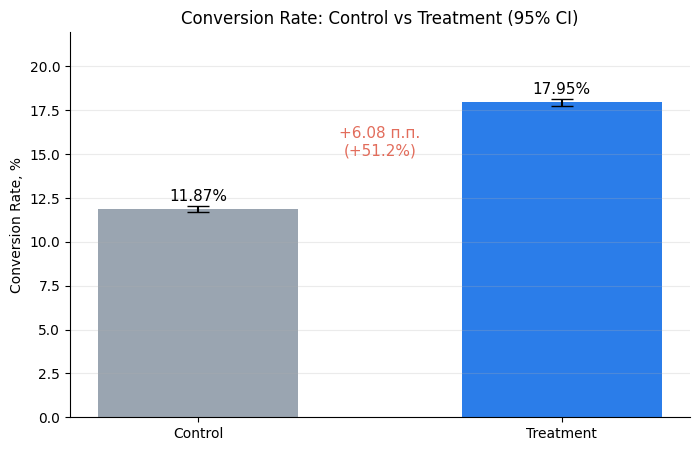

In [17]:
import matplotlib.pyplot as plt

# Подготовка данных
groups = ['Control', 'Treatment']
crs = np.array([control_cr, treatment_cr])
conversion_rates = crs * 100

ci_half = 1.96 * np.sqrt(crs * (1 - crs) / users) * 100

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(groups, conversion_rates, yerr=ci_half, capsize=8, color=['#9aa5b1', '#2b7de9'], width=0.55)

for bar, value, err in zip(bars, conversion_rates, ci_half):
    ax.text(bar.get_x() + bar.get_width() / 2, value + err + 0.3, f'{value:.2f}%', ha='center', fontsize=11)

# Подпись с размером эффекта между столбцами
ax.annotate(f'+{absolute_uplift * 100:.2f} п.п.\n(+{relative_uplift:.1%})',
            xy=(0.5, (conversion_rates.max() + conversion_rates.min()) / 2), ha='center', fontsize=11, color='#e26d5c')

# Оформление графика
ax.set_title('Conversion Rate: Control vs Treatment (95% CI)')
ax.set_ylabel('Conversion Rate, %')
ax.set_ylim(0, conversion_rates.max() + 4)
ax.grid(axis='y', alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

Визуальное сравнение показывает заметное преимущество тестовой версии landing page.

Conversion Rate увеличилась с **11.87% в Control до 17.95% в Treatment**, что соответствует абсолютному росту на **6.08 процентного пункта** и относительному росту на **51.18%**.

Полученный результат подтверждён статистическим тестом и 95% доверительным интервалом, поэтому наблюдаемое преимущество Treatment имеет статистическое подтверждение.

### Анализ эффекта по сегментам

После оценки общего эффекта проверяется, как он проявляется в разных сегментах пользователей: по типу устройства, стране, полу и возрастной группе. Пользовательский опыт на лендинге может зависеть, например, от устройства, поэтому важно убедиться, что эффект не обеспечен одним сегментом.

Для каждого сегмента рассчитываются uplift (п.п.), 95% доверительный интервал разницы и p-value z-теста. Так как одновременно проверяется много сегментов, p-value корректируется поправкой **Холма** (контроль вероятности ложноположительных результатов). Основной вывод эксперимента при этом не зависит от сегментов — они носят исследовательский характер.

In [18]:
# Расширенный сегментный анализ
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep
from statsmodels.stats.multitest import multipletests

# Возрастные группы для анализа по возрасту 
df['age_group'] = pd.cut(
    df['age'],
    bins=[17, 24, 34, 44, 65],
    labels=['18-24', '25-34', '35-44', '45-65']
)

# Признаки, по которым делится выборка на сегменты
segment_columns = ['device_type', 'location', 'gender', 'age_group']

rows = []
for col in segment_columns:
    for value, part in df.groupby(col, observed=True):
        c = part[part['group'] == 'control']['converted']
        t = part[part['group'] == 'treatment']['converted']

        z, p = proportions_ztest([t.sum(), c.sum()], [len(t), len(c)])
        low, high = confint_proportions_2indep(t.sum(), len(t), c.sum(), len(c), method='wald')

        rows.append({
            'segment': col,
            'value': value,
            'users': len(part),
            'control_cr, %': c.mean() * 100,
            'treatment_cr, %': t.mean() * 100,
            'uplift_pp': (t.mean() - c.mean()) * 100,
            'ci_low_pp': low * 100,
            'ci_high_pp': high * 100,
            'p_value': p
        })

segments_all = pd.DataFrame(rows)
segments_all['p_value_holm'] = multipletests(segments_all['p_value'], method='holm')[1]

segments_all.round({'control_cr, %': 2, 'treatment_cr, %': 2, 'uplift_pp': 2,
                    'ci_low_pp': 2, 'ci_high_pp': 2, 'p_value': 4, 'p_value_holm': 4})

,segment,value,users,"control_cr, %","treatment_cr, %",uplift_pp,ci_low_pp,ci_high_pp,p_value,p_value_holm
0,device_type,Desktop,176692,11.95,18.08,6.13,5.80,6.46,0.0,0.0
1,device_type,Mobile,103093,11.74,17.71,5.97,5.54,6.40,0.0,0.0
2,device_type,Tablet,14693,11.85,18.01,6.16,5.01,7.31,0.0,0.0
3,location,Australia,14587,11.87,17.98,6.11,4.96,7.26,0.0,0.0
4,location,Canada,29241,12.24,17.87,5.63,4.81,6.44,0.0,0.0
5,location,Germany,29477,11.55,17.77,6.22,5.41,7.02,0.0,0.0
6,location,India,59014,11.81,18.20,6.38,5.81,6.96,0.0,0.0
7,location,Pakistan,29600,11.75,18.01,6.26,5.45,7.07,0.0,0.0
8,location,UK,44217,12.05,17.79,5.74,5.08,6.40,0.0,0.0
9,location,US,88342,11.85,17.92,6.07,5.61,6.54,0.0,0.0


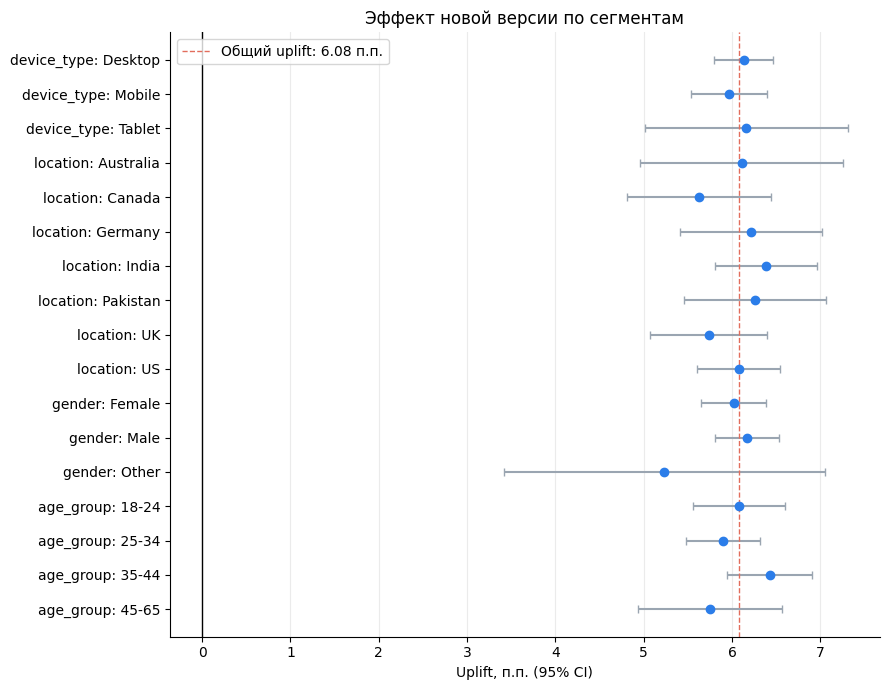

In [19]:
# Forest plot
# Подготовка данных
plot_df = segments_all.copy()
plot_df['label'] = plot_df['segment'] + ': ' + plot_df['value'].astype(str)
plot_df = plot_df.iloc[::-1].reset_index(drop=True) 
y_pos = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(9, 7))
ax.errorbar(
    plot_df['uplift_pp'], y_pos,
    xerr=[plot_df['uplift_pp'] - plot_df['ci_low_pp'], plot_df['ci_high_pp'] - plot_df['uplift_pp']],
    fmt='o', color='#2b7de9', ecolor='#9aa5b1', capsize=3
)
# Чёрная линия — нулевой эффект; красный пунктир — общий uplift по всей выборке
ax.axvline(0, color='black', linewidth=1)
ax.axvline(absolute_uplift * 100, color='#e26d5c', linestyle='--', linewidth=1,
           label=f'Общий uplift: {absolute_uplift * 100:.2f} п.п.')

# Подписи и оформление
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df['label'])
ax.set_xlabel('Uplift, п.п. (95% CI)')
ax.set_title('Эффект новой версии по сегментам')
ax.legend(loc='upper left')
ax.grid(axis='x', alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

**Результат.** Во всех 17 сегментах (4 типа признаков) uplift положительный, а по устройствам почти одинаковый: Desktop +6.13 п.п., Mobile +5.97 п.п., Tablet +6.16 п.п. В целом разброс от +5.23 п.п. (пол «Other», самая малочисленная группа, ~6 тыс. пользователей) до +6.42 п.п. (возраст 35–44). Доверительные интервалы нигде не включают 0, p-value после поправки Холма < 0.001 во всех сегментах. Новая версия работает примерно одинаково для всех аудиторий.

### Выручка и вторичные метрики

Основная метрика эксперимента — Conversion Rate. Но рост конверсии не гарантирует роста денег: если новая версия привлекает более «дешёвые» покупки, выручка на пользователя может не вырасти. Поэтому дополнительно сравниваются:

- **ARPU** — средняя выручка на пользователя (включая нулевые покупки);
- **AOV** — средний чек среди пользователей, совершивших покупку;
- **session_duration** и **pages_visited** — как guardrail-метрики (не ухудшилось ли поведение на сайте).

Для ARPU доверительный интервал разницы строится методом bootstrap (распределение сильно скошено и содержит много нулей), для остальных метрик используется Welch t-test, а для AOV — дополнительно Mann–Whitney.

In [20]:
# Статистическое сравнение выручки и вторичных метрик
from scipy.stats import ttest_ind, mannwhitneyu

# Разделение выборки на контрольную и тестовую группы
control = df[df['group'] == 'control']
treatment = df[df['group'] == 'treatment']

# Генератор случайных чисел с фиксированным seed — результат bootstrap воспроизводится
rng = np.random.default_rng(42)

# --- ARPU: разница и bootstrap 95% CI
c_rev = control['purchase_amount'].to_numpy()
t_rev = treatment['purchase_amount'].to_numpy()

# Bootstrap
n_boot = 1000
boot_diff = np.empty(n_boot)
for i in range(n_boot):
    boot_diff[i] = (rng.choice(t_rev, size=len(t_rev)).mean()
                    - rng.choice(c_rev, size=len(c_rev)).mean())

arpu_diff = t_rev.mean() - c_rev.mean()
arpu_ci_low, arpu_ci_high = np.percentile(boot_diff, [2.5, 97.5])
_, arpu_p = ttest_ind(t_rev, c_rev, equal_var=False)

print(f'ARPU: control = {c_rev.mean():.2f}, treatment = {t_rev.mean():.2f}')
print(f'Разница ARPU: {arpu_diff:+.2f} ({arpu_diff / c_rev.mean():+.1%}), 95% bootstrap CI [{arpu_ci_low:.2f}; {arpu_ci_high:.2f}], Welch p = {arpu_p:.4g}')

c_aov = control.loc[control['converted'] == 1, 'purchase_amount']
t_aov = treatment.loc[treatment['converted'] == 1, 'purchase_amount']
_, aov_t_p = ttest_ind(t_aov, c_aov, equal_var=False)
_, aov_u_p = mannwhitneyu(t_aov, c_aov, alternative='two-sided')

print(f'\nAOV: control = {c_aov.mean():.2f}, treatment = {t_aov.mean():.2f} ({t_aov.mean() / c_aov.mean() - 1:+.1%})')
print(f'AOV: Welch p = {aov_t_p:.4g}, Mann-Whitney p = {aov_u_p:.4g}')

for metric in ['session_duration', 'pages_visited']:
    _, p = ttest_ind(treatment[metric], control[metric], equal_var=False)
    print(f'{metric}: control = {control[metric].mean():.2f}, treatment = {treatment[metric].mean():.2f}, Welch p = {p:.4g}')

ARPU: control = 4.45, treatment = 6.76
Разница ARPU: +2.31 (+51.9%), 95% bootstrap CI [2.20; 2.42], Welch p = 0

AOV: control = 37.50, treatment = 37.68 (+0.5%)
AOV: Welch p = 0.3622, Mann-Whitney p = 0.243
session_duration: control = 5.00, treatment = 5.00, Welch p = 0.672
pages_visited: control = 4.02, treatment = 4.02, Welch p = 0.2446


**Результат.** ARPU вырос с 4.45 (control) до 6.76 (treatment): **+2.31 (+51.9%)**, 95% bootstrap CI [2.20; 2.42], Welch p < 0.001.

AOV практически не изменился: 37.50 против 37.68 (+0.5%, Welch p = 0.36, Mann–Whitney p = 0.24). Значит, рост выручки на пользователя полностью объясняется ростом конверсии, а не размером покупки: новая версия не «размывает» средний чек.

Guardrail-метрики без изменений: `session_duration` 5.00 против 5.00 (p = 0.67), `pages_visited` 4.02 против 4.02 (p = 0.24).

### Чувствительность эксперимента: MDE и размер выборки

Расчёт мощности «по уже наблюдённому эффекту» (post-hoc power) не несёт новой информации: при маленьком p-value он всегда даёт почти 100%. Поэтому вместо него оценивается **чувствительность дизайна** эксперимента — то есть рассматриваются вопросы, которые аналитик задаёт *до* запуска теста:

1. Какая выборка нужна, чтобы с мощностью 80% и α = 0.05 обнаружить эффект заданного размера (при базовой конверсии контроля)?
2. Какой минимальный эффект (**MDE**, Minimum Detectable Effect) мог обнаружить тест при фактическом размере групп?

Ориентировочный результат для baseline CR ≈ 11.87%, α = 0.05, мощность 80%: для обнаружения +0.5 п.п. нужно порядка 67 тыс. пользователей в группе, для +1 п.п. — около 17 тыс., для +2 п.п. — около 4.4 тыс. При фактических ~147 тыс. пользователей в группе минимальный обнаруживаемый эффект составляет примерно 0.34 п.п. Точные значения рассчитываются в ячейке ниже.

In [21]:
# Чувствительность эксперимента: размер выборки и минимальный обнаруживаемый эффект (MDE)
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

analysis = NormalIndPower()
baseline = control_cr          
alpha, target_power = 0.05, 0.80

for mde_pp in [0.5, 1.0, 2.0]:
    es = proportion_effectsize(baseline + mde_pp / 100, baseline)
    n_required = analysis.solve_power(effect_size=es, alpha=alpha, power=target_power, ratio=1.0, alternative='two-sided')
    print(f'MDE = +{mde_pp:.1f} п.п. -> нужно ~{int(np.ceil(n_required)):,} пользователей в каждой группе')

es_min = analysis.solve_power(nobs1=users[0], alpha=alpha, power=target_power,
                              ratio=users[1] / users[0], alternative='two-sided')
p_min = np.sin((2 * np.arcsin(np.sqrt(baseline)) + es_min) / 2) ** 2
print(f'\nФактически группы: {users[0]:,} и {users[1]:,}')
print(f'Минимальный обнаруживаемый эффект (мощность {target_power:.0%}): +{(p_min - baseline) * 100:.2f} п.п.')
print(f'Наблюдаемый эффект: +{absolute_uplift * 100:.2f} п.п. — в разы больше MDE')

MDE = +0.5 п.п. -> нужно ~66,885 пользователей в каждой группе
MDE = +1.0 п.п. -> нужно ~17,013 пользователей в каждой группе
MDE = +2.0 п.п. -> нужно ~4,396 пользователей в каждой группе

Фактически группы: 146,926 и 147,552
Минимальный обнаруживаемый эффект (мощность 80%): +0.34 п.п.
Наблюдаемый эффект: +6.08 п.п. — в разы больше MDE


Наблюдаемый эффект (+6.08 п.п.) многократно превышает MDE, поэтому размер выборки был более чем достаточен для его обнаружения. Обратная сторона: такой большой uplift для одного изменения лендинга — необычный результат, и перед внедрением его стоит перепроверить (корректность логирования, отсутствие багов, эффект новизны).

## Итоговые выводы и рекомендации

**Результат по основной метрике.**
- Conversion Rate вырос с 11.87% (control) до 17.95% (treatment): абсолютный прирост **+6.08 п.п.** (95% CI: 5.82–6.33 п.п.), относительный — **+51.18%**.
- Различие статистически значимо (z-тест для двух пропорций, z ≈ 46, p-value < 0.001).
- Эффект устойчив: положительный и статистически значимый во всех 17 сегментах (устройство, страна, пол, возраст).

**Выручка.** ARPU вырос на 2.31 (+51.9%, 95% CI [2.20; 2.42]) при неизменном AOV (+0.5%, не значимо) и неизменных `session_duration` и `pages_visited`: рост денег обеспечен именно ростом конверсии.

**Корректность эксперимента** (ноутбук 01): SRM не обнаружен, группы сбалансированы по полу, устройству, стране и возрасту, соответствие группы и версии страницы полное. Мощность более чем достаточна: минимальный обнаруживаемый эффект ≈ 0.34 п.п. при наблюдаемых 6.08 п.п.

**Рекомендация.** Новую версию лендинга стоит **внедрять для всех пользователей**: она значимо повышает конверсию и выручку на пользователя, не ухудшая средний чек и поведенческие метрики.

**Ограничения:**
- Размер эффекта (+51% относительного роста) необычно велик для изменения лендинга. Кроме того, у данных есть признаки синтетического происхождения (идентичные `session_duration` и `pages_visited` у покупателей и не покупателей). Поэтому результаты стоит воспринимать как демонстрацию методологии; на реальных данных перед раскаткой нужно исключить ошибки логирования, а динамику эффекта во времени (эффект новизны) проверить отдельно.
- Тест единичный, нет данных о предрегистрации длительности и MDE.
- Сегментный анализ носит исследовательский характер.

**Следующие шаги (для реального продукта):** поэтапная раскатка (например, 50% → 100% трафика) с мониторингом CR и выручки и повторная проверка эффекта на новом периоде.